# Push example
The default behavior of `jupyter_rfb` is to automatically call `get_frame()` when a new draw is requested and when the widget is ready for it. In use-cases where you want to push frames to the widget, you may prefer a different approach.

Here is the native solution:

RFBOutputContext()


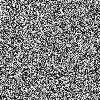

In [1]:
import numpy as np
from jupyter_rfb import RemoteFrameBuffer

w1 = RemoteFrameBuffer(css_width="100px", css_height="100px")
w1.display()

In [2]:
# Push 20 frames.
for _ in range(20):
    w1.send_frame(np.random.uniform(0, 255, (100, 100)).astype(np.uint8))

The above works, but has a risk of overloading the IO if more frames are send then can be send over the network.

The below example is a more robust alternative:

RFBOutputContext()


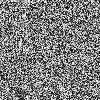

In [3]:
import numpy as np
from jupyter_rfb import RemoteFrameBuffer


class FramePusher(RemoteFrameBuffer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._queue = []

    def push_frame(self, frame):
        self._queue.append(frame)
        self._queue[:-10] = []  # drop older frames if len > 10
        self.request_draw()

    def get_frame(self):
        if not self._queue:
            return
        self.request_draw()
        return self._queue.pop(0)


w2 = FramePusher(css_width="100px", css_height="100px")
w2.display()

In [4]:
for _ in range(20):
    w2.send_frame(np.random.uniform(0, 255, (100, 100)).astype(np.uint8))